# Tumoroid polygon annotation

Steps:
1. **Imports**: import libraries, load data
2. **Adata reconstruction**: rebuild adata subsets from the JSON
3. **Wilcoxon test**: Wilcoxon tests and summary

## Imports:
1. **Imports:**  
This cell loads all the necessary libraries and builds the AnnData object from the expression matrix and the H&E image.
`shapely` is used to manipulate polygons, `cmath` for angular sorting of points.
The scalefactor retrieved here converts spot coordinates to pixel coordinates in the image.

In [13]:
import sys, os, json, cmath
sys.path.append('/home/lili/Documents/M1/S2/stage/the_during/phase1/scripts')
from CreateSquidpyBMKObject import create_s1000_object
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, Point
from scipy import stats


matrix_path = '/home/lili/Documents/M1/S2/stage/the_during/phase1/scripts/level_1/level_1'
png_path    = '/home/lili/Documents/M1/S2/stage/the_during/phase1/scripts/level_1/pics/he_roi_small.png'

adata = create_s1000_object(
    matrix_path, png_path,
    spot_radius=1, min_cells=5, min_features=40, resolution='spot'
)

scalef    = adata.uns['spatial']['sample1']['scalefactors']['tissue_hires_scalef']
he_image  = adata.uns['spatial']['sample1']['images']['hires']
coords    = adata.obsm['spatial']
n_genes   = adata.obs['n_genes'].values

JSON_PATH = 'polygones_tumoroids.json'

print('Data loaded.')
print(f'  {adata.n_obs} spots, {adata.n_vars} genes')

Data loaded.
  167598 spots, 26283 genes


## Analysis:
2. **Adata reconstruction**  
Once all polygons are available in the JSON, we reload them and build one `adata` subset per tumoroid. For each spot, `shapely` tests whether it falls inside the corresponding polygon.

In [14]:
# Reload the JSON in case the kernel was restarted
with open(JSON_PATH) as f:
    polygons_data = json.load(f)

polygons = {name: Polygon(pts) for name, pts in polygons_data.items()}

adata_tumoroids = {}
for name in sorted(polygons):
    poly = polygons[name]
    mask = np.array([poly.contains(Point(x, y)) for x, y in coords])
    adata_t = adata[mask].copy()
    adata_tumoroids[name] = adata_t
    print(f'{name}: {adata_t.n_obs} spots')

T1: 5765 spots
T2: 12888 spots
T3: 10524 spots
T4: 9159 spots
T5: 7333 spots
T6: 17896 spots
T7: 5499 spots
T8: 9284 spots
T9: 10496 spots


### Wilcoxon Mann-Whitney on polygons:
3. **Wilcoxon test:**  
For each tumoroid, we compute the distance of each spot to the centroid of all spots in that tumoroid. We then compare the distance distributions between VEGFA+ and VEGFA- spots using a one-sided Wilcoxon test (`alternative='less'`). The hypothesis tested is that VEGFA+ spots are significantly closer to the centre. P-values are then corrected for multiple testing using Benjamini-Hochberg (BH) across all 18 tests (9 tumoroids × 2 genes).

In [15]:
from statsmodels.stats.multitest import multipletests

results = {}

for name, adata_t in sorted(adata_tumoroids.items()):
    coords_t  = adata_t.obsm['spatial']
    centre    = coords_t.mean(axis=0)
    distances = np.linalg.norm(coords_t - centre, axis=1)
    results[name] = {}

    for gene in ['VEGFA', 'MKI67']:
        if gene not in adata_t.var_names:
            results[name][gene] = {'n': 0, 'pval': float('nan')}
            continue

        idx  = list(adata_t.var_names).index(gene)
        expr = np.asarray(adata_t.X[:, idx].todense()).flatten()
        expressed = expr > 0
        d_pos = distances[expressed]
        d_neg = distances[~expressed]

        if len(d_pos) < 3:
            results[name][gene] = {'n': int(expressed.sum()), 'pval': float('nan'),
                                   'med_pos': float('nan'), 'med_neg': float('nan')}
            continue

        _, pval = stats.mannwhitneyu(d_pos, d_neg, alternative='less')
        results[name][gene] = {
            'n':       int(expressed.sum()),
            'pval':    float(pval),
            'med_pos': float(np.median(d_pos)),
            'med_neg': float(np.median(d_neg)),
        }

genes = ['VEGFA', 'MKI67']
keys  = [(name, gene) for name in sorted(results) for gene in genes]
pvals = [results[name][gene].get('pval', float('nan')) for name, gene in keys]

isnan       = lambda v: isinstance(v, float) and v != v
valid_mask  = [not isnan(p) for p in pvals]
valid_pvals = [p for p, m in zip(pvals, valid_mask) if m]

_, qvals_valid, _, _ = multipletests(valid_pvals, method='fdr_bh')

q_iter = iter(qvals_valid)
for (name, gene), is_valid in zip(keys, valid_mask):
    results[name][gene]['qval'] = float(next(q_iter)) if is_valid else float('nan')

# print results with raw p and BH-adjusted q
for name in sorted(results):
    for gene in genes:
        r = results[name][gene]
        if r['n'] == 0 or isnan(r['pval']):
            continue
        sig = 'sig.' if r['qval'] < 0.05 else 'not sig.'
        print(f'{name} {gene} ({r["n"]} spots): p={r["pval"]:.2e}  q={r["qval"]:.2e} — {sig}')
    print()

T1 VEGFA (5 spots): p=8.63e-01  q=9.84e-01 — not sig.
T1 MKI67 (102 spots): p=2.63e-01  q=5.26e-01 — not sig.

T2 VEGFA (50 spots): p=2.03e-10  q=1.22e-09 — sig.
T2 MKI67 (162 spots): p=7.77e-01  q=9.84e-01 — not sig.

T3 VEGFA (13 spots): p=9.28e-01  q=9.84e-01 — not sig.
T3 MKI67 (142 spots): p=6.72e-02  q=2.02e-01 — not sig.

T4 VEGFA (8 spots): p=5.04e-01  q=7.56e-01 — not sig.
T4 MKI67 (106 spots): p=1.07e-01  q=2.76e-01 — not sig.

T5 VEGFA (16 spots): p=9.21e-03  q=3.31e-02 — sig.
T5 MKI67 (66 spots): p=5.00e-01  q=7.56e-01 — not sig.

T6 VEGFA (109 spots): p=8.17e-16  q=1.47e-14 — sig.
T6 MKI67 (203 spots): p=1.00e+00  q=1.00e+00 — not sig.

T7 VEGFA (10 spots): p=6.21e-01  q=8.60e-01 — not sig.
T7 MKI67 (72 spots): p=9.30e-01  q=9.84e-01 — not sig.

T8 VEGFA (52 spots): p=3.59e-06  q=1.61e-05 — sig.
T8 MKI67 (80 spots): p=2.02e-01  q=4.54e-01 — not sig.

T9 VEGFA (69 spots): p=2.98e-12  q=2.68e-11 — sig.
T9 MKI67 (84 spots): p=4.80e-01  q=7.56e-01 — not sig.



**Summary table**  
This table groups the results for VEGFA and MKI67 across all tumoroids. The q-value is the BH-adjusted p-value — significance is assessed on q < 0.05.

In [16]:
# Summary table
header = (f"{'Tumoroid':10} {'VEGFA n':8} {'VEGFA p':10} {'VEGFA q':10} {'VEGFA':10} "
          f"{'MKI67 n':8} {'MKI67 p':10} {'MKI67 q':10} {'MKI67':10}")
print(header)
print('-' * len(header))

isnan = lambda v: isinstance(v, float) and v != v
fmt   = lambda v: f'{v:.2e}' if not isnan(v) else '-'
sig   = lambda q: ('sig.' if q < 0.05 else 'not sig.') if not isnan(q) else '-'

for name in sorted(results):
    r = results[name]

    for g in ['VEGFA', 'MKI67']:
        if g not in r:
            r[g] = {'n': '-', 'pval': float('nan'), 'qval': float('nan')}

    vn = r['VEGFA']['n'];  vp = r['VEGFA']['pval'];  vq = r['VEGFA'].get('qval', float('nan'))
    mn = r['MKI67']['n'];  mp = r['MKI67']['pval'];  mq = r['MKI67'].get('qval', float('nan'))

    print(f'{name:10} {str(vn):8} {fmt(vp):10} {fmt(vq):10} {sig(vq):10} '
          f'{str(mn):8} {fmt(mp):10} {fmt(mq):10} {sig(mq):10}')

Tumoroid   VEGFA n  VEGFA p    VEGFA q    VEGFA      MKI67 n  MKI67 p    MKI67 q    MKI67     
----------------------------------------------------------------------------------------------
T1         5        8.63e-01   9.84e-01   not sig.   102      2.63e-01   5.26e-01   not sig.  
T2         50       2.03e-10   1.22e-09   sig.       162      7.77e-01   9.84e-01   not sig.  
T3         13       9.28e-01   9.84e-01   not sig.   142      6.72e-02   2.02e-01   not sig.  
T4         8        5.04e-01   7.56e-01   not sig.   106      1.07e-01   2.76e-01   not sig.  
T5         16       9.21e-03   3.31e-02   sig.       66       5.00e-01   7.56e-01   not sig.  
T6         109      8.17e-16   1.47e-14   sig.       203      1.00e+00   1.00e+00   not sig.  
T7         10       6.21e-01   8.60e-01   not sig.   72       9.30e-01   9.84e-01   not sig.  
T8         52       3.59e-06   1.61e-05   sig.       80       2.02e-01   4.54e-01   not sig.  
T9         69       2.98e-12   2.68e-11   sig.    

**VEGFA / MKI67 visualization per tumoroid**  
We display side by side the expression maps of VEGFA and MKI67 for each tumoroid. Grey spots do not express the gene, red spots do (darker = stronger expression). The red outline is the annotated polygon.

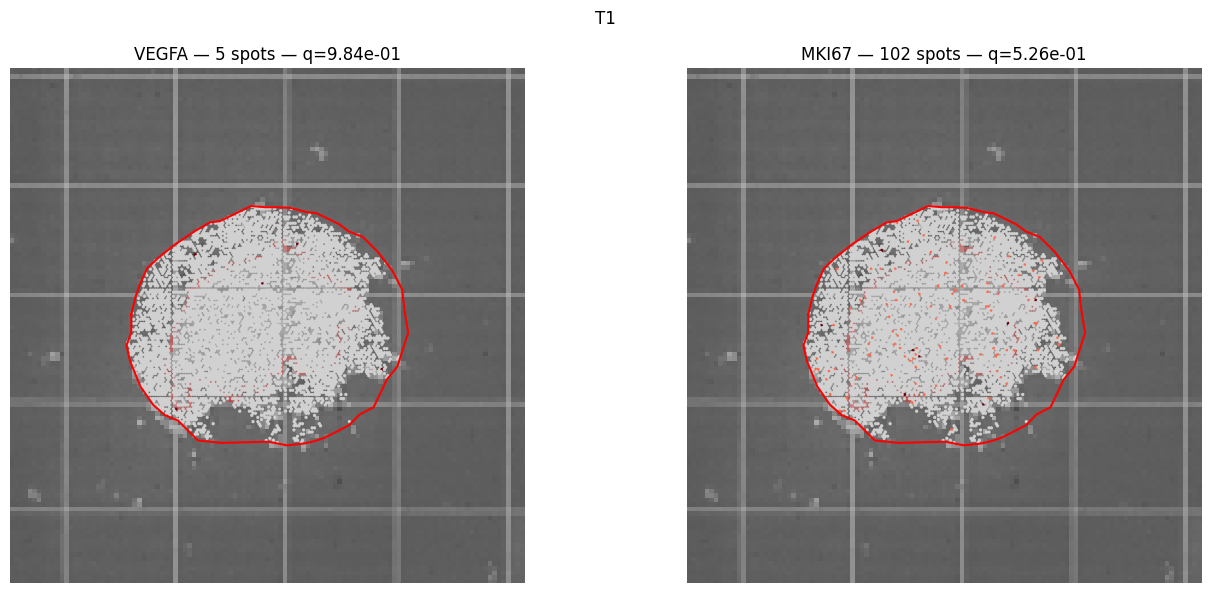

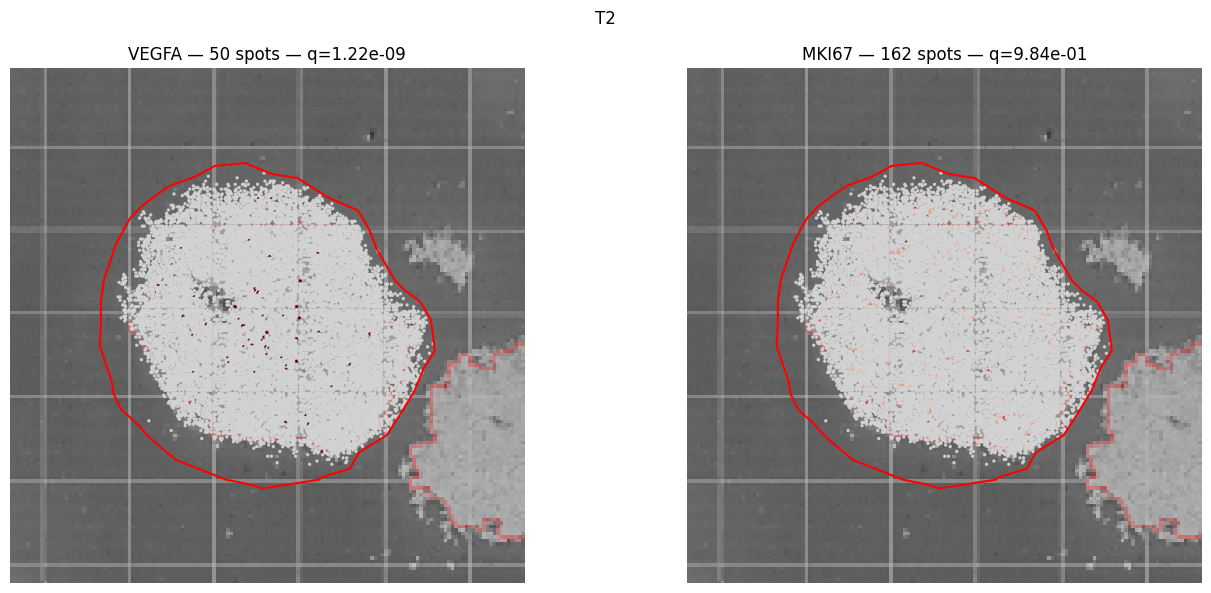

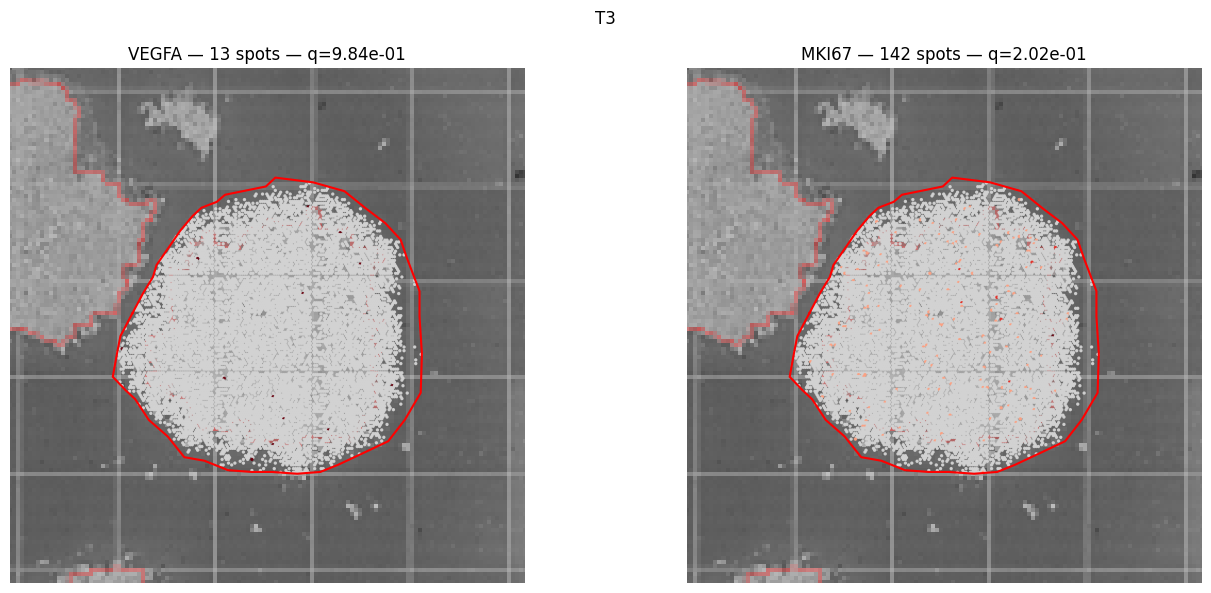

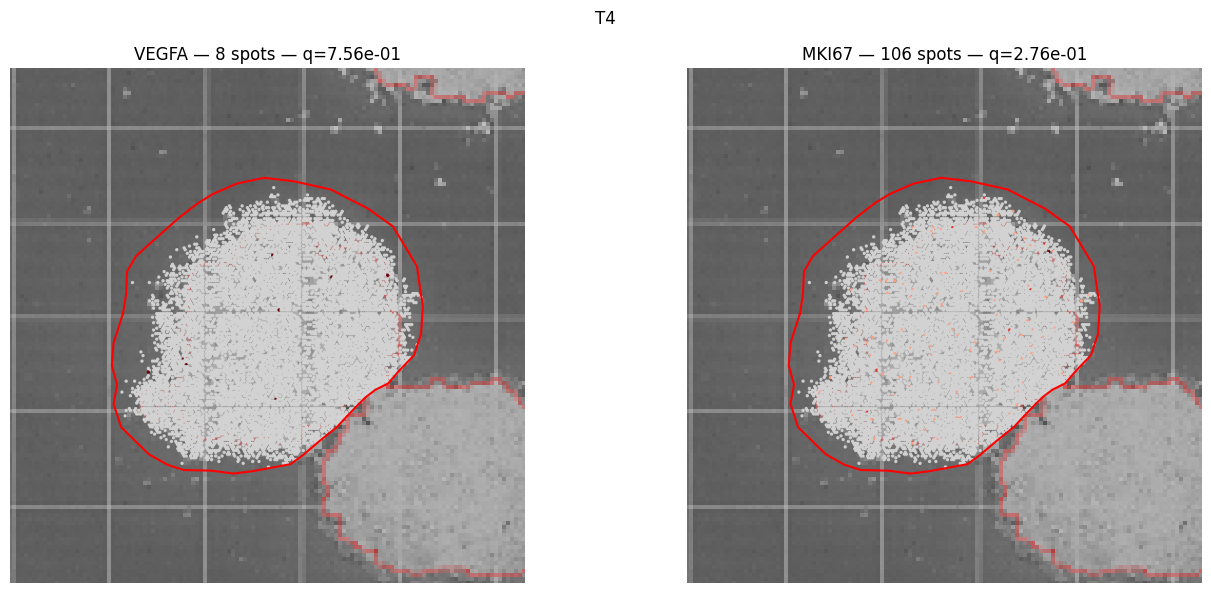

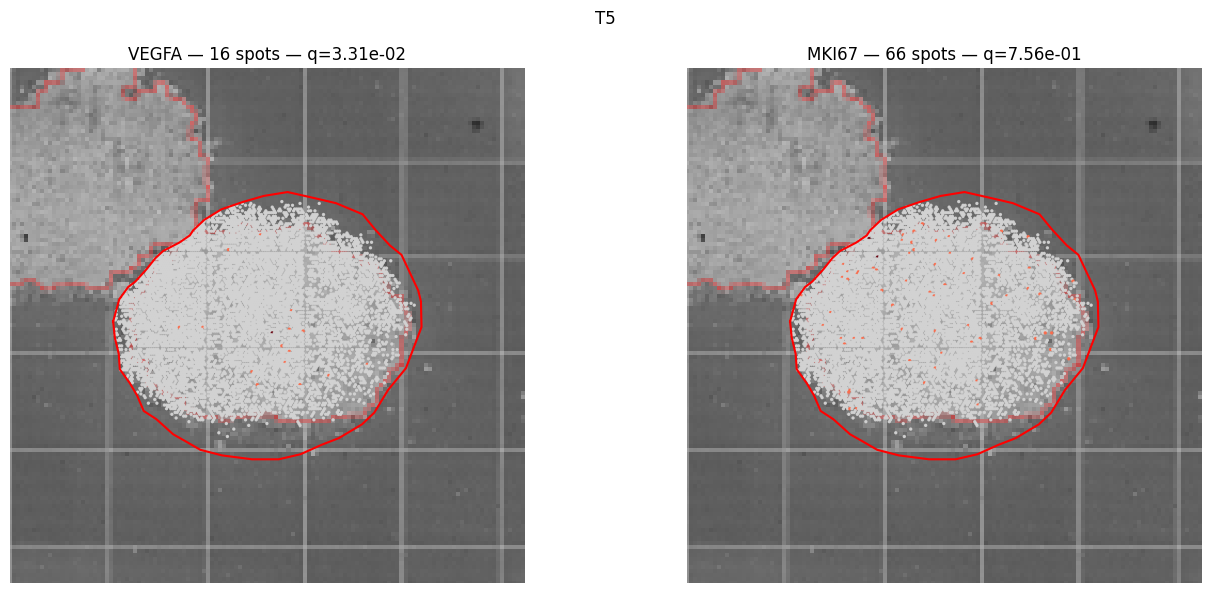

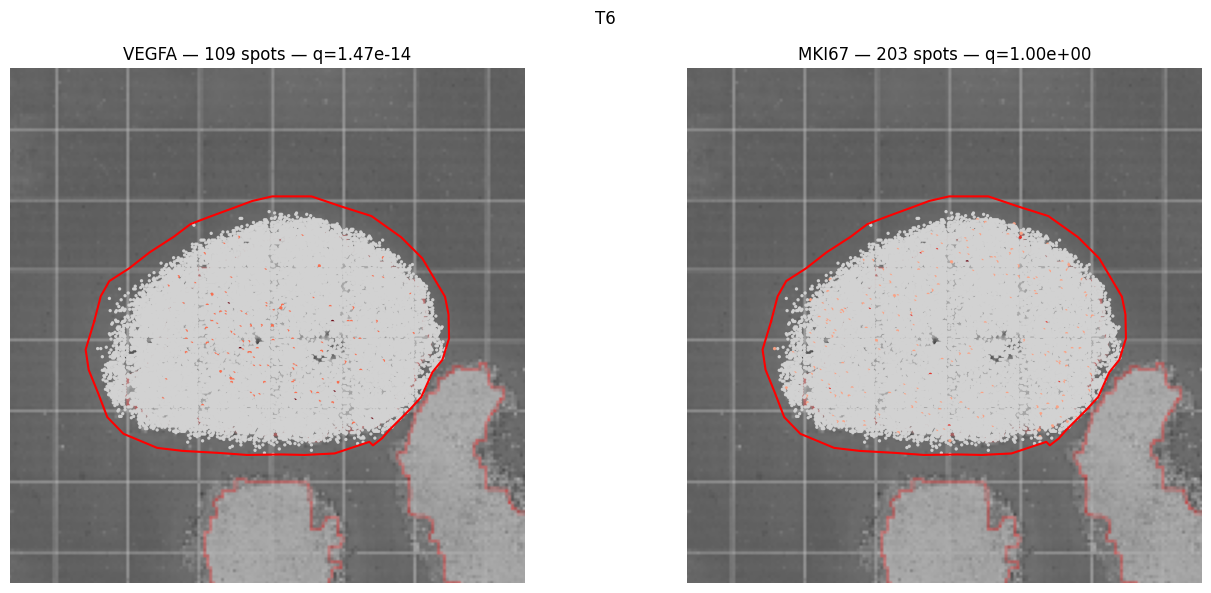

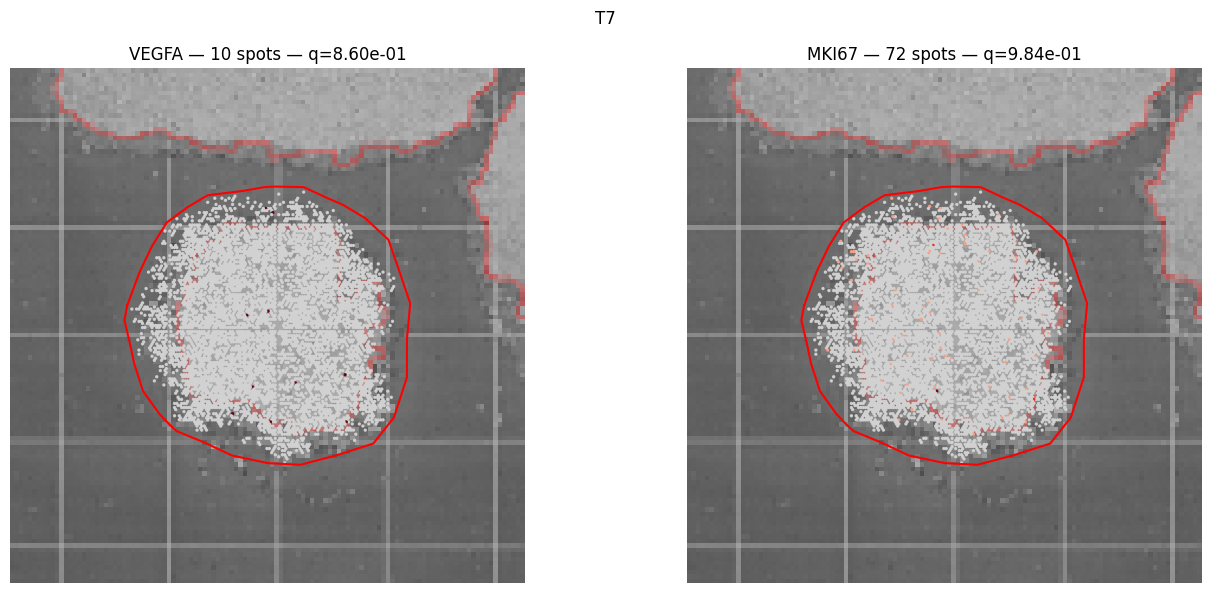

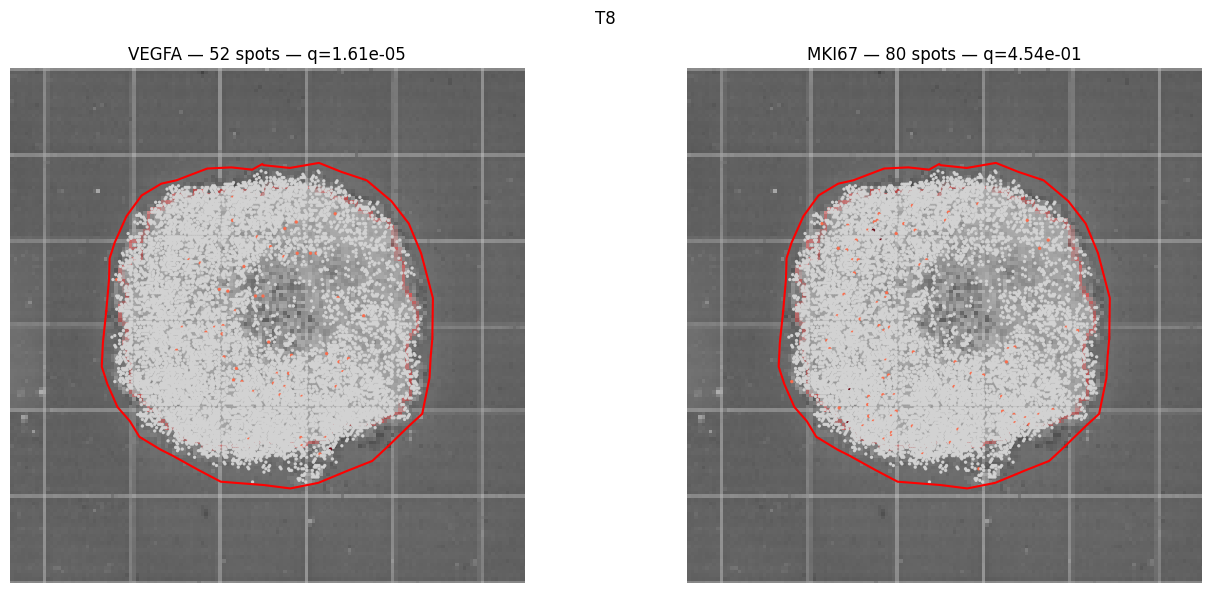

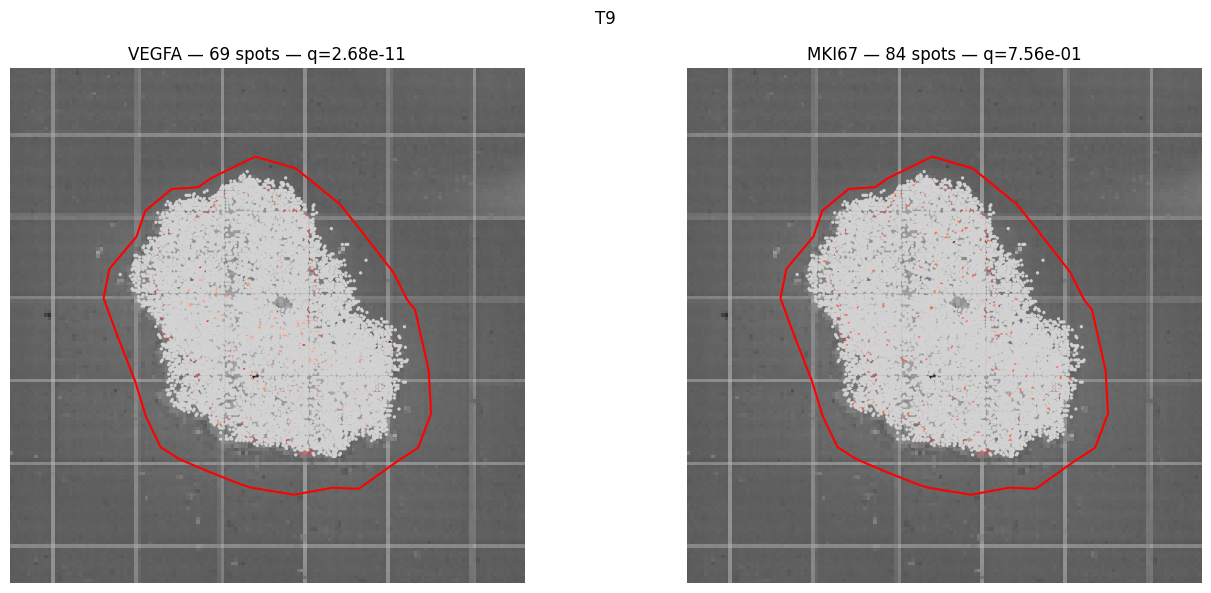

In [17]:
%matplotlib inline

cmap_reds = plt.cm.Reds.copy()
cmap_reds.set_under('lightgray')

for name in sorted(adata_tumoroids):
    adata_t  = adata_tumoroids[name]
    coords_t = adata_t.obsm['spatial']
    poly     = polygons[name]

    x_p, y_p = poly.exterior.xy
    cx     = (max(x_p) + min(x_p)) / 2
    cy     = (max(y_p) + min(y_p)) / 2
    margin = max(max(x_p) - min(x_p), max(y_p) - min(y_p)) / 2 + 25

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(name, fontsize=12)

    for ax, gene in zip(axes, ['VEGFA', 'MKI67']):
        if gene in adata_t.var_names:
            idx  = list(adata_t.var_names).index(gene)
            expr = np.asarray(adata_t.X[:, idx].todense()).flatten()
        else:
            expr = np.zeros(adata_t.n_obs)

        ax.imshow(he_image, cmap='gray')
        ax.scatter(coords_t[:, 0] * scalef, coords_t[:, 1] * scalef,
                   c=expr, s=2, cmap=cmap_reds, alpha=0.9, vmin=0.01)

        ax.plot(np.array(x_p) * scalef, np.array(y_p) * scalef,
                color='red', linewidth=1.5)

        ax.set_xlim((cx - margin) * scalef, (cx + margin) * scalef)
        ax.set_ylim((cy + margin) * scalef, (cy - margin) * scalef)

        r_info = results.get(name, {}).get(gene, {})
        n_expr = r_info.get('n', '?')
        qval   = r_info.get('qval', float('nan'))
        qlabel = f'q={qval:.2e}' if not (isinstance(qval, float) and qval != qval) else 'q=?'
        ax.set_title(f'{gene} — {n_expr} spots — {qlabel}')
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(f'visu_polygone_{name}.png', dpi=120, bbox_inches='tight')
    plt.show()

In [18]:
from statsmodels.stats.multitest import multipletests

# directional hypothesis per gene: VEGFA expected central, MKI67 expected peripheral
alternatives = {'VEGFA': 'less', 'MKI67': 'greater'}

results = {}
for name, adata_t in sorted(adata_tumoroids.items()):
    coords_t  = adata_t.obsm['spatial']
    centre    = coords_t.mean(axis=0)
    distances = np.linalg.norm(coords_t - centre, axis=1)
    results[name] = {}
    for gene in ['VEGFA', 'MKI67']:
        if gene not in adata_t.var_names:
            results[name][gene] = {'n': 0, 'pval': float('nan')}
            continue
        idx  = list(adata_t.var_names).index(gene)
        expr = np.asarray(adata_t.X[:, idx].todense()).flatten()
        expressed = expr > 0
        d_pos = distances[expressed]
        d_neg = distances[~expressed]
        if len(d_pos) < 3:
            results[name][gene] = {'n': int(expressed.sum()), 'pval': float('nan'),
                                   'med_pos': float('nan'), 'med_neg': float('nan')}
            continue
        _, pval = stats.mannwhitneyu(d_pos, d_neg, alternative=alternatives[gene])
        results[name][gene] = {
            'n':       int(expressed.sum()),
            'pval':    float(pval),
            'med_pos': float(np.median(d_pos)),
            'med_neg': float(np.median(d_neg)),
        }

isnan = lambda v: isinstance(v, float) and v != v

# BH correction run separately within each gene
genes = ['VEGFA', 'MKI67']
for gene in genes:
    names       = sorted(results)
    pvals       = [results[name][gene].get('pval', float('nan')) for name in names]
    valid_mask  = [not isnan(p) for p in pvals]
    valid_pvals = [p for p, m in zip(pvals, valid_mask) if m]
    if valid_pvals:
        _, qvals_valid, _, _ = multipletests(valid_pvals, method='fdr_bh')
        q_iter = iter(qvals_valid)
        for name, is_valid in zip(names, valid_mask):
            results[name][gene]['qval'] = float(next(q_iter)) if is_valid else float('nan')
    else:
        for name in names:
            results[name][gene]['qval'] = float('nan')

# print results with raw p and BH-adjusted q
for name in sorted(results):
    for gene in genes:
        r = results[name][gene]
        if r['n'] == 0 or isnan(r['pval']):
            continue
        sig = 'sig.' if r['qval'] < 0.05 else 'not sig.'
        print(f'{name} {gene} ({r["n"]} spots): p={r["pval"]:.2e}  q={r["qval"]:.2e} — {sig}')
    print()

T1 VEGFA (5 spots): p=8.63e-01  q=9.28e-01 — not sig.
T1 MKI67 (102 spots): p=7.37e-01  q=9.33e-01 — not sig.

T2 VEGFA (50 spots): p=2.03e-10  q=6.08e-10 — sig.
T2 MKI67 (162 spots): p=2.23e-01  q=6.69e-01 — not sig.

T3 VEGFA (13 spots): p=9.28e-01  q=9.28e-01 — not sig.
T3 MKI67 (142 spots): p=9.33e-01  q=9.33e-01 — not sig.

T4 VEGFA (8 spots): p=5.04e-01  q=7.56e-01 — not sig.
T4 MKI67 (106 spots): p=8.93e-01  q=9.33e-01 — not sig.

T5 VEGFA (16 spots): p=9.21e-03  q=1.66e-02 — sig.
T5 MKI67 (66 spots): p=5.00e-01  q=9.33e-01 — not sig.

T6 VEGFA (109 spots): p=8.17e-16  q=7.35e-15 — sig.
T6 MKI67 (203 spots): p=8.11e-05  q=7.30e-04 — sig.

T7 VEGFA (10 spots): p=6.21e-01  q=7.99e-01 — not sig.
T7 MKI67 (72 spots): p=7.05e-02  q=3.17e-01 — not sig.

T8 VEGFA (52 spots): p=3.59e-06  q=8.07e-06 — sig.
T8 MKI67 (80 spots): p=7.98e-01  q=9.33e-01 — not sig.

T9 VEGFA (69 spots): p=2.98e-12  q=1.34e-11 — sig.
T9 MKI67 (84 spots): p=5.20e-01  q=9.33e-01 — not sig.

